# Neural Network Model

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

https://numpy.org/doc/2.4/reference/generated/numpy.array.html#numpy.array
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.index.html

## Load all feature files

In [157]:
# Helper function to clean numeric columns
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

In [158]:
# State hospital features
state_hospitals = pd.read_csv("Features/State_Hospitals.csv", header=3)
state_hospitals.columns = state_hospitals.columns.str.strip()
state_hospitals = state_hospitals[state_hospitals["Provider State/Other"].notna()].copy()

hospital_cols = [
    "Provider State/Other",
    "Skilled Nursing Facility Beds Per 1,000 Part A Enrollees",
    "Short Stay Hospital Beds Per 1,000 Part A Enrollees",
    "Critical Access Hospital Beds Per 1,000 Part A Enrollees",
    "All Other Hospital Beds Per 1,000 Part A Enrollees"
]
state_hospitals = state_hospitals[hospital_cols].copy()

# State provider features
providers = pd.read_csv("Features/State_Providers.csv", header=2)
providers.columns = providers.columns.str.strip()
providers = providers[providers["Provider State/Other"].notna()].copy()

provider_cols = [
    "Provider State/Other",
    "Independent and Clinical Labs",
    "Ambulatory Surgical Centers",
    "Comprehensive Outpatient Rehabilitation Facilities",
    "Rural Health Clinics",
    "Federally Qualified Health Centers",
    "Hospices"
]
providers = providers[provider_cols].copy()

# State level payments
payments = pd.read_csv("Features/States_MedicarePaymentsandEnrollment.csv", header=3)
payments.columns = payments.columns.str.strip()
payments = payments[payments["Area of Residence"].notna()].copy()

payment_cols = [
    "Area of Residence",
    "Medicare Part A and/or Part B Program Payments Per Person With Utilization",
    "Medicare Part A and/or Part B Program Payments Per Original Medicare Enrollee"
]
payments = payments[payment_cols].copy()

# State level non institutional providers
noninst_providers = pd.read_csv("Features/States_NonInstitutional_Providers.csv", header=3)
noninst_providers.columns = noninst_providers.columns.str.strip()
noninst_providers = noninst_providers[noninst_providers["State/Other"].notna()].copy()

noninst_cols = ["State/Other", "2023"]
noninst_providers = noninst_providers[noninst_cols].copy()

print("Hospitals:", state_hospitals.shape)
print("Providers:", providers.shape)
print("Payments:", payments.shape)
print("Noninstitutional:", noninst_providers.shape)

Hospitals: (57, 5)
Providers: (57, 7)
Payments: (61, 3)
Noninstitutional: (61, 2)


## Clean and merge feature table

In [159]:
# Remove summary rows
bad_rows = ["All Areas", "United States"]

state_hospitals = state_hospitals[~state_hospitals["Provider State/Other"].isin(bad_rows)].copy()
providers = providers[~providers["Provider State/Other"].isin(bad_rows)].copy()
payments = payments[~payments["Area of Residence"].isin(bad_rows)].copy()
noninst_providers = noninst_providers[~noninst_providers["State/Other"].isin(bad_rows)].copy()

In [160]:
# Merge state level feature tables
feature_df = (
    state_hospitals
    .merge(providers, on="Provider State/Other", how="left")
    .merge(payments, left_on="Provider State/Other", right_on="Area of Residence", how="left")
    .merge(noninst_providers, left_on="Provider State/Other", right_on="State/Other", how="left")
    .drop(columns=["Area of Residence", "State/Other"])
    .rename(columns={
        "Provider State/Other": "State",
        "2023": "Noninstitutional Providers 2023"
    })
)

feature_df.head()
print("Feature df shape:", feature_df.shape)


Feature df shape: (55, 14)


# Load and prepare target values

In [161]:
inpatient_values = pd.read_csv("Predicted_values/MUP_INP_RY25_P03_V10_DY23_PrvSvc.csv")
inpatient_values.columns = inpatient_values.columns.str.strip()

inpatient_values = inpatient_values[inpatient_values["DRG_Desc"].str.contains("FEMALE")]

inpatient_values["DRG_Desc"].unique()

inpatient_drg_list = [
    "FEMALE REPRODUCTIVE SYSTEM RECONSTRUCTIVE PROCEDURES",
    "OTHER FEMALE REPRODUCTIVE SYSTEM O.R. PROCEDURES WITH CC/MCC",
    "MALIGNANCY, FEMALE REPRODUCTIVE SYSTEM WITH CC",
    "MALIGNANCY, FEMALE REPRODUCTIVE SYSTEM WITH MCC", 
    "D&C, CONIZATION, LAPAROSCOPY AND TUBAL INTERRUPTION WITH CC/MCC"
]

filtered_inpatient = inpatient_values[
    inpatient_values["DRG_Desc"].isin(inpatient_drg_list)
].copy()

filtered_inpatient["Tot_Dschrgs"] = pd.to_numeric(
    filtered_inpatient["Tot_Dschrgs"], errors="coerce"
)

state_inpatient_targets = (
    filtered_inpatient
    .groupby("Rndrng_Prvdr_State_Abrvtn", as_index=False)["Tot_Dschrgs"]
    .sum()
    .rename(columns={
        "Rndrng_Prvdr_State_Abrvtn": "State Abbrev",
        "Tot_Dschrgs": "Total Inpatient Discharges"
    })
)

state_inpatient_targets.head()

,State Abbrev,Total Inpatient Discharges
0,CA,13
1,CO,14
2,FL,57
3,IN,13
4,MA,40


In [162]:
outpatient_values = pd.read_csv("Predicted_values/MUP_OUT_RY25_P04_V10_DY23_Prov_Svc.csv")
outpatient_values.columns = outpatient_values.columns.str.strip()

# We included laparoscopy based off our research
target_apc_list = [
    "Level 1 Laparoscopy and Related Services",
    "Level 2 Laparoscopy and Related Services",
    "Level 4 Gynecologic Procedures",
    "Level 5 Gynecologic Procedures",
    "Level 6 Gynecologic Procedures"
]

filtered_outpatient = outpatient_values[
    outpatient_values["APC_Desc"].isin(target_apc_list)
].copy()

filtered_outpatient["Bene_Cnt"] = pd.to_numeric(
    filtered_outpatient["Bene_Cnt"], errors="coerce"
)

state_outpatient_targets = (
    filtered_outpatient
    .groupby("Rndrng_Prvdr_State_Abrvtn", as_index=False)["Bene_Cnt"]
    .sum()
    .rename(columns={
        "Rndrng_Prvdr_State_Abrvtn": "State Abbrev",
        "Bene_Cnt": "Total Outpatient Beneficiaries"
    })
)

state_outpatient_targets.head()

,State Abbrev,Total Outpatient Beneficiaries
0,AK,717.0
1,AL,4249.0
2,AR,3715.0
3,AZ,7443.0
4,CA,22800.0


In [163]:
state_targets = state_inpatient_targets.merge(
    state_outpatient_targets,
    on="State Abbrev",
    how="outer"
)

state_targets["Total Inpatient Discharges"] = state_targets["Total Inpatient Discharges"].fillna(0)
state_targets["Total Outpatient Beneficiaries"] = state_targets["Total Outpatient Beneficiaries"].fillna(0)

state_targets["Total Utilization"] = (
    state_targets["Total Inpatient Discharges"] +
    state_targets["Total Outpatient Beneficiaries"]
)

print(state_targets.head())

  State Abbrev  Total Inpatient Discharges  Total Outpatient Beneficiaries  \
0           AK                         0.0                           717.0   
1           AL                         0.0                          4249.0   
2           AR                         0.0                          3715.0   
3           AZ                         0.0                          7443.0   
4           CA                        13.0                         22800.0   

   Total Utilization  
0              717.0  
1             4249.0  
2             3715.0  
3             7443.0  
4            22813.0  


## Map state names to abbreviations

In [164]:
state_name_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

feature_df["State Abbrev"] = feature_df["State"].map(state_name_to_abbrev)

## Assemble model dataframe

In [165]:
model_df = feature_df.merge(state_targets, on="State Abbrev", how="inner")

print("Model df shape:", model_df.shape)
print(model_df[["State",
                "State Abbrev", 
                "Total Inpatient Discharges",
                "Total Outpatient Beneficiaries",
                "Total Utilization"
]].head())

feature_columns = [
    "Skilled Nursing Facility Beds Per 1,000 Part A Enrollees",
    "Short Stay Hospital Beds Per 1,000 Part A Enrollees",
    "Critical Access Hospital Beds Per 1,000 Part A Enrollees",
    "All Other Hospital Beds Per 1,000 Part A Enrollees",
    "Medicare Part A and/or Part B Program Payments Per Person With Utilization",
    "Medicare Part A and/or Part B Program Payments Per Original Medicare Enrollee",
    "Noninstitutional Providers 2023"
]

Model df shape: (50, 18)
        State State Abbrev  Total Inpatient Discharges  \
0     Alabama           AL                         0.0   
1      Alaska           AK                         0.0   
2     Arizona           AZ                         0.0   
3    Arkansas           AR                         0.0   
4  California           CA                        13.0   

   Total Outpatient Beneficiaries  Total Utilization  
0                          4249.0             4249.0  
1                           717.0              717.0  
2                          7443.0             7443.0  
3                          3715.0             3715.0  
4                         22800.0            22813.0  


## Clean model features

In [166]:
for col in feature_columns:
    model_df[col] = clean_numeric(model_df[col])

model_df["Total Utilization"] = pd.to_numeric(model_df["Total Utilization"], errors="coerce")

model_df = model_df.dropna(subset=["Total Utilization"]).reset_index(drop=True)

for col in feature_columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print("Model df shape:", model_df.shape)

Model df shape: (50, 18)


## Train test split

In [167]:
X_df = model_df[feature_columns].copy()
y_df = model_df["Total Utilization"].copy()

n_total = len(model_df)
rng = np.random.default_rng(8)
all_idx = np.arange(n_total)
rng.shuffle(all_idx)

train_size = int(0.8 * n_total)
train_idx = all_idx[:train_size]
test_idx = all_idx[train_size:]

X_train_df = X_df.iloc[train_idx].copy()
X_test_df = X_df.iloc[test_idx].copy()
y_train_df = y_df.iloc[train_idx].copy()
y_test_df = y_df.iloc[test_idx].copy()

print(X_train_df)

    Skilled Nursing Facility Beds Per 1,000 Part A Enrollees  \
14                                               36.9          
16                                               30.3          
1                                                 7.3          
40                                               26.6          
0                                                24.1          
15                                               39.1          
11                                               13.9          
29                                               29.7          
39                                               16.7          
25                                               21.0          
5                                                18.8          
41                                               23.6          
13                                               32.3          
36                                               10.7          
12                                      

## Standardize

In [168]:
train_means = X_train_df.mean()
train_stds = X_train_df.std().replace(0, 1)

X_train = ((X_train_df - train_means) / train_stds).to_numpy(dtype=float)
X_test = ((X_test_df - train_means) / train_stds).to_numpy(dtype=float)

y_train_mean = y_train_df.mean()
y_train_std = y_train_df.std()

if y_train_std == 0:
    y_train_std = 1

y_train = ((y_train_df - y_train_mean) / y_train_std).to_numpy(dtype=float)
y_test = ((y_test_df - y_train_mean) / y_train_std).to_numpy(dtype=float)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training points:", len(y_train))
print("Test points:", len(y_test))

Training shape: (40, 7)
Testing shape: (10, 7)
Training points: 40
Test points: 10


## Neural network definitions

In [169]:
eta = 0.3
epochs = 300
lam = 0.01

def forward_pass_with_weights(input_x, W1, b1, W2, b2):
    x = np.reshape(input_x, (-1, 1))
    h_pre = W1.T @ x + b1
    h = np.maximum(0, h_pre)
    y_hat = (W2.T @ h + b2).item()
    return y_hat, h, h_pre

def predict_matrix(Xmat, W1, b1, W2, b2):
    preds = []
    for i in range(Xmat.shape[0]):
        y_hat, h, h_pre = forward_pass_with_weights(Xmat[i], W1, b1, W2, b2)
        preds.append(y_hat)
    return np.array(preds)

def get_Ws(W1, b1, W2, b2, X, Y, d, n):
    train_errors = []

    for epoch in range(epochs):
        dW1 = np.zeros_like(W1)
        db1 = np.zeros_like(b1)
        dW2 = np.zeros_like(W2)
        db2 = np.zeros_like(b2)

        for i in range(n):
            x = np.reshape(X[i], (d, 1))
            y_true = Y[i]

            h_pre = W1.T @ x + b1
            h = np.maximum(0, h_pre)
            y_hat = (W2.T @ h + b2).item()

            error = y_hat - y_true

            dW2 += (2 / n) * error * h
            db2 += (2 / n) * error

            relu_grad = (h_pre > 0).astype(float)
            hidden_effect = W2 * relu_grad

            dW1 += (2 / n) * error * (x @ hidden_effect.T)
            db1 += (2 / n) * error * hidden_effect

        dW1 += 2 * lam * W1
        dW2 += 2 * lam * W2

        W1 = W1 - eta * dW1
        b1 = b1 - eta * db1
        W2 = W2 - eta * dW2
        b2 = b2 - eta * db2

        train_preds = predict_matrix(X, W1, b1, W2, b2)
        train_mse = np.mean((train_preds - Y) ** 2)
        train_errors.append(train_mse)

        if np.isnan(train_mse) or np.isinf(train_mse):
            break

    return train_mse, W1, b1, W2, b2, train_errors

## Find best random seed using LOOCV on training data

In [170]:
results_list = []

X_train_df = X_train_df.reset_index(drop=True)
y_train_df = y_train_df.reset_index(drop=True)

hidden_nodes = 1

for seed in range(50):
    fold_mses = []

    for row in range(len(X_train_df)):
        X_cv_test_df = X_train_df.iloc[[row]].copy()
        y_cv_test_df = float(y_train_df.iloc[row])

        X_cv_train_df = X_train_df.drop(row, axis=0).copy()
        y_cv_train_df = y_train_df.drop(row, axis=0).copy()

        fold_means = X_cv_train_df.mean()
        fold_stds = X_cv_train_df.std().replace(0, 1)

        X_cv_train = ((X_cv_train_df - fold_means) / fold_stds).to_numpy(dtype=float)
        X_cv_test = ((X_cv_test_df - fold_means) / fold_stds).to_numpy(dtype=float)

        y_cv_mean = y_cv_train_df.mean()
        y_cv_std = y_cv_train_df.std()
        if y_cv_std == 0:
            y_cv_std = 1

        y_cv_train = ((y_cv_train_df - y_cv_mean) / y_cv_std).to_numpy(dtype=float)
        y_cv_test = (y_cv_test_df - y_cv_mean) / y_cv_std

        d = X_cv_train.shape[1]
        n = X_cv_train.shape[0]

        np.random.seed(seed)
        W1 = np.random.randn(d, hidden_nodes) * 0.1
        W2 = np.random.randn(hidden_nodes, 1) * 0.1
        b1 = np.zeros((hidden_nodes, 1))
        b2 = np.zeros((1, 1))

        fit_result = get_Ws(W1, b1, W2, b2, X_cv_train, y_cv_train, d, n)
        W1_fit = fit_result[1]
        b1_fit = fit_result[2]
        W2_fit = fit_result[3]
        b2_fit = fit_result[4]

        pred_cv, h_cv, hpre_cv = forward_pass_with_weights(
            X_cv_test[0], W1_fit, b1_fit, W2_fit, b2_fit
        )

        fold_mse = (pred_cv - y_cv_test) ** 2

        if not np.isnan(fold_mse) and not np.isinf(fold_mse):
            fold_mses.append(fold_mse)

    if len(fold_mses) > 0:
        avg_cv_mse = np.mean(fold_mses)
    else:
        avg_cv_mse = np.nan

    results_list.append((hidden_nodes, seed, avg_cv_mse))

results_df = pd.DataFrame(results_list, columns=["Hidden_Nodes", "Seed", "Average_CV_MSE"])
print(results_df)

clean_results_df = results_df.dropna(subset=["Average_CV_MSE"]).copy()

best_row = clean_results_df.loc[clean_results_df["Average_CV_MSE"].idxmin()]
best_seed = int(best_row["Seed"])
best_cv_mse = best_row["Average_CV_MSE"]

print("Best seed:", best_seed)
print("Best CV MSE:", best_cv_mse)

    Hidden_Nodes  Seed  Average_CV_MSE
0              1     0        0.091467
1              1     1        0.825363
2              1     2        0.715290
3              1     3        0.593829
4              1     4        0.826150
5              1     5        0.895380
6              1     6        0.846562
7              1     7        0.923045
8              1     8        0.103969
9              1     9        0.688331
10             1    10        0.076693
11             1    11        0.487828
12             1    12        0.950835
13             1    13        0.161346
14             1    14        0.644750
15             1    15        0.708209
16             1    16        0.899673
17             1    17        0.091307
18             1    18        0.168102
19             1    19        0.161680
20             1    20        1.043911
21             1    21        0.686827
22             1    22        0.917183
23             1    23        0.679415
24             1    24   

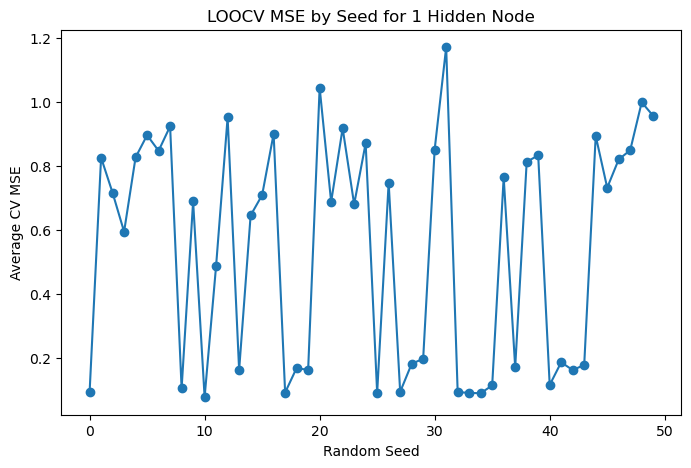

In [171]:
# We selected the seed with the lowest validation error and used that configuration for the final model.
plt.figure(figsize=(8, 5))
plt.plot(results_df["Seed"], results_df["Average_CV_MSE"], marker="o")
plt.title("LOOCV MSE by Seed for 1 Hidden Node")
plt.xlabel("Random Seed")
plt.ylabel("Average CV MSE")
plt.show()

## Train final model

In [172]:
d = X_train.shape[1]
n = X_train.shape[0]

hidden_nodes = 1
seed = 10

np.random.seed(seed)
W1 = np.random.randn(d, hidden_nodes) * 0.1
b1 = np.zeros((hidden_nodes, 1))
W2 = np.random.randn(hidden_nodes, 1) * 0.1
b2 = np.zeros((1, 1))

final_result = get_Ws(W1, b1, W2, b2, X_train, y_train, d, n)

final_W1 = final_result[1]
final_b1 = final_result[2]
final_W2 = final_result[3]
final_b2 = final_result[4]
train_errors = final_result[5]

train_preds_scaled = predict_matrix(X_train, final_W1, final_b1, final_W2, final_b2)
test_preds_scaled = predict_matrix(X_test, final_W1, final_b1, final_W2, final_b2)

train_preds = train_preds_scaled * y_train_std + y_train_mean
test_preds = test_preds_scaled * y_train_std + y_train_mean

y_train_original = y_train_df.to_numpy(dtype=float)
y_test_original = y_test_df.to_numpy(dtype=float)

train_mse = np.mean((train_preds - y_train_original) ** 2)
test_mse = np.mean((test_preds - y_test_original) ** 2)

print("Hidden nodes used:", hidden_nodes)
print("Seed used:", seed)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Hidden nodes used: 1
Seed used: 10
Train MSE: 1307097.0298521144
Test MSE: 1136590.8013256777


## Plot actual vs predicted

    Actual     Predicted
0   1799.0   2062.166784
1  22813.0  22638.579271
2   9371.0   7095.983771
3   1045.0   2062.166784
4   3689.0   3242.863500
5   3049.0   4256.050990
6   9527.0   8065.490172
7  13234.0  12750.218931
8   2608.0   2062.166784
9   7443.0   6587.486885


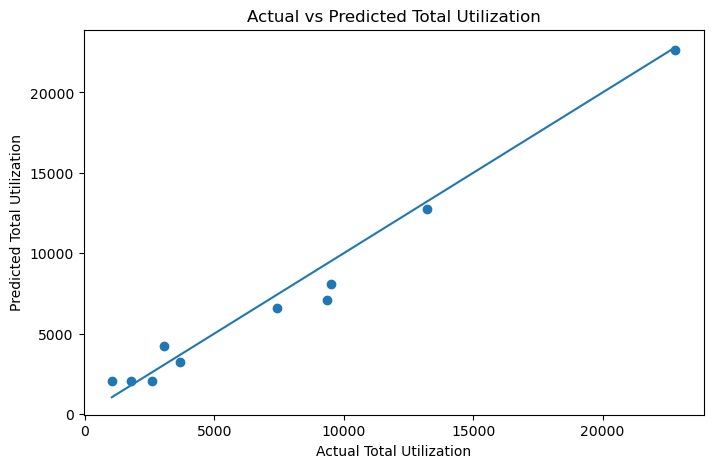

In [173]:
comparison_df = pd.DataFrame({
    "Actual": y_test_original,
    "Predicted": test_preds
})

print(comparison_df)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_original, test_preds)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()]
)
plt.title("Actual vs Predicted Total Utilization")
plt.xlabel("Actual Total Utilization")
plt.ylabel("Predicted Total Utilization")
plt.show()

## Plot training error

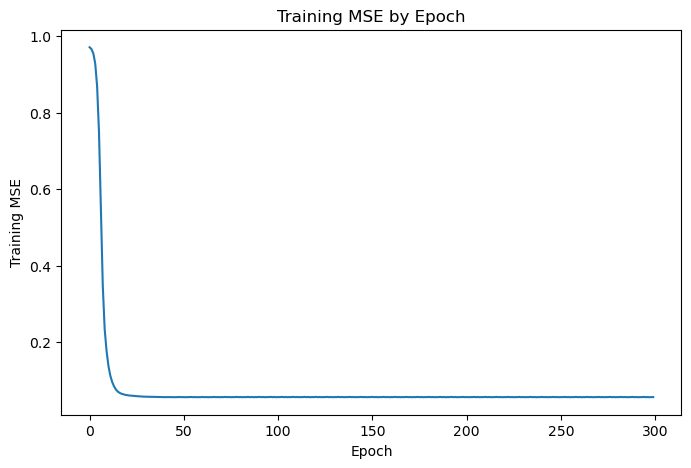

In [174]:
plt.figure(figsize=(8, 5))
plt.plot(train_errors)
plt.title("Training MSE by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.show()

In [175]:
baseline_pred = np.repeat(y_train_original.mean(), len(y_test_original))
baseline_mse = np.mean((baseline_pred - y_test_original) ** 2)
baseline_rmse = np.sqrt(baseline_mse)

nn_rmse = np.sqrt(test_mse)

print("Baseline MSE:", baseline_mse)
print("Baseline RMSE:", baseline_rmse)
print("Neural Network RMSE:", nn_rmse)

Baseline MSE: 45266462.900625005
Baseline RMSE: 6728.035590023659
Neural Network RMSE: 1066.1101262654238
